# Inferencia tipo Mandani

In [1]:
# Librerias
import matplotlib.pyplot as plt
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [2]:
# CONFIGURACIÓN DE LOS DATOS 

# Variable 1: Toxicidad (0-10)
toxicidad = {
    'Baja':  {'x': [0, 2, 4],    'y': [1, 1, 0], 'color': 'blue'},
    'Media': {'x': [3, 5, 7],    'y': [0, 1, 0], 'color': 'green'},
    'Alta':  {'x': [6, 8, 10],   'y': [0, 1, 1], 'color': 'red'}
}

# Variable 2: Subjetividad (0-10)
subjetividad = {
    'Objetiva':       {'x': [0, 4, 4],   'y': [1, 0, 0], 'color': 'blue'}, # Triángulo inicial
    'Subjetiva':      {'x': [3, 6, 9],   'y': [0, 1, 0], 'color': 'green'},
    'Muy Subjetiva':  {'x': [7, 9, 10],  'y': [0, 1, 1], 'color': 'red'}
}

# Variable 3: Nivel de Alerta (0-100)
alerta = {
    'Nulo':     {'x': [0, 15, 30],   'y': [1, 1, 0], 'color': 'blue'},
    'Moderado': {'x': [25, 50, 75],  'y': [0, 1, 0], 'color': 'orange'},
    'Crítico':  {'x': [70, 90, 100], 'y': [0, 1, 1], 'color': 'red'}
}

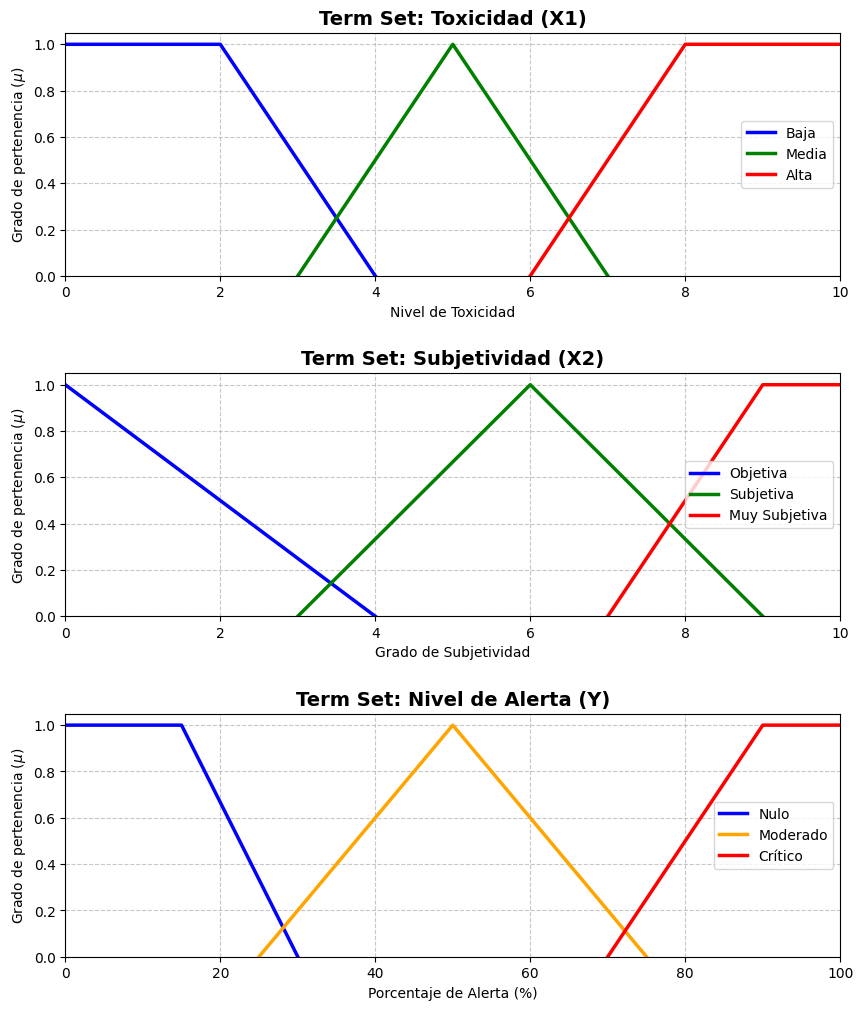

In [3]:
# CREACIÓN DE LAS GRÁFICAS

fig, axs = plt.subplots(3, 1, figsize=(10, 12))
plt.subplots_adjust(hspace=0.4)

def plot_fuzzy_var(ax, data, title, xlabel, xlim):
    for label, params in data.items():
        ax.plot(params['x'], params['y'], label=label, color=params['color'], linewidth=2.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Grado de pertenencia ($\mu$)')
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, xlim)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='center right')

# Graficar cada variable
plot_fuzzy_var(axs[0], toxicidad, 'Term Set: Toxicidad (X1)', 'Nivel de Toxicidad', 10)
plot_fuzzy_var(axs[1], subjetividad, 'Term Set: Subjetividad (X2)', 'Grado de Subjetividad', 10)
plot_fuzzy_var(axs[2], alerta, 'Term Set: Nivel de Alerta (Y)', 'Porcentaje de Alerta (%)', 100)

plt.show()

Resultado Nivel de Alerta: 88.37%


C:\Users\willi\AppData\Local\Programs\Python\Python313\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


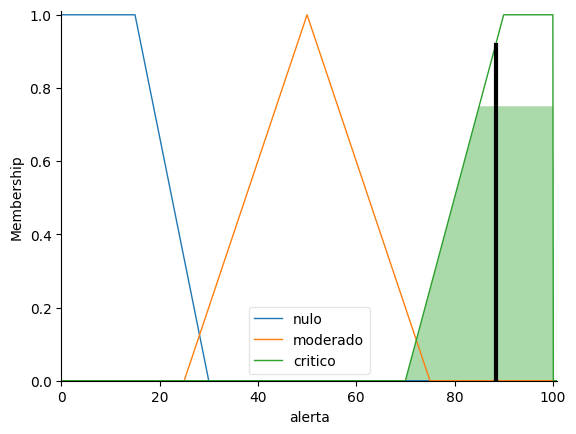

In [4]:
# --- 1. CONVERTIR TUS DICCIONARIOS A OBJETOS DE SKFUZZY ---
tox_ctrl = ctrl.Antecedent(np.arange(0, 11, 0.1), 'toxicidad')
subj_ctrl = ctrl.Antecedent(np.arange(0, 11, 0.1), 'subjetividad')
alerta_ctrl = ctrl.Consequent(np.arange(0, 101, 0.1), 'alerta')

# Mapeo automático de tus coordenadas (x, y) a funciones de skfuzzy
tox_ctrl['baja'] = fuzz.trapmf(tox_ctrl.universe, [0, 0, 2, 4])
tox_ctrl['media'] = fuzz.trimf(tox_ctrl.universe, [3, 5, 7])
tox_ctrl['alta'] = fuzz.trapmf(tox_ctrl.universe, [6, 8, 10, 10])

subj_ctrl['objetiva'] = fuzz.trimf(subj_ctrl.universe, [0, 0, 4])
subj_ctrl['subjetiva'] = fuzz.trimf(subj_ctrl.universe, [3, 6, 9])
subj_ctrl['muy_subjetiva'] = fuzz.trapmf(subj_ctrl.universe, [7, 9, 10, 10])

alerta_ctrl['nulo'] = fuzz.trapmf(alerta_ctrl.universe, [0, 0, 15, 30])
alerta_ctrl['moderado'] = fuzz.trimf(alerta_ctrl.universe, [25, 50, 75])
alerta_ctrl['critico'] = fuzz.trapmf(alerta_ctrl.universe, [70, 90, 100, 100])

# --- 2. DEFINICIÓN DE LAS 5 REGLAS ---
r1 = ctrl.Rule(tox_ctrl['alta'] & subj_ctrl['muy_subjetiva'], alerta_ctrl['critico'])
r2 = ctrl.Rule(tox_ctrl['media'] & subj_ctrl['subjetiva'], alerta_ctrl['moderado'])
r3 = ctrl.Rule(tox_ctrl['alta'] & subj_ctrl['objetiva'], alerta_ctrl['moderado'])
r4 = ctrl.Rule(tox_ctrl['baja'], alerta_ctrl['nulo'])
r5 = ctrl.Rule(subj_ctrl['objetiva'], alerta_ctrl['nulo'])

# --- 3. EJECUCIÓN DEL ESCENARIO (Toxicidad 7.5, Subjetividad 8.5) ---
sistema = ctrl.ControlSystem([r1, r2, r3, r4, r5])
simulacion = ctrl.ControlSystemSimulation(sistema)

simulacion.input['toxicidad'] = 7.5
simulacion.input['subjetividad'] = 8.5

# Calcular Desborrosificación (Centro de Gravedad)
simulacion.compute()

print(f"Resultado Nivel de Alerta: {simulacion.output['alerta']:.2f}%")

# Para ver la gráfica de salida con el área sombreada y el resultado:
alerta_ctrl.view(sim=simulacion)
plt.show()

<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
C:\Users\willi\AppData\Local\Temp\ipykernel_17524\2188763992.py:53: SyntaxWarning: invalid escape sequence '\m'
  ax.text(input_val + 0.1, mu_val + 0.02, f'$\mu({label}) = {mu_val:.2f}$', color='black', fontweight='bold')


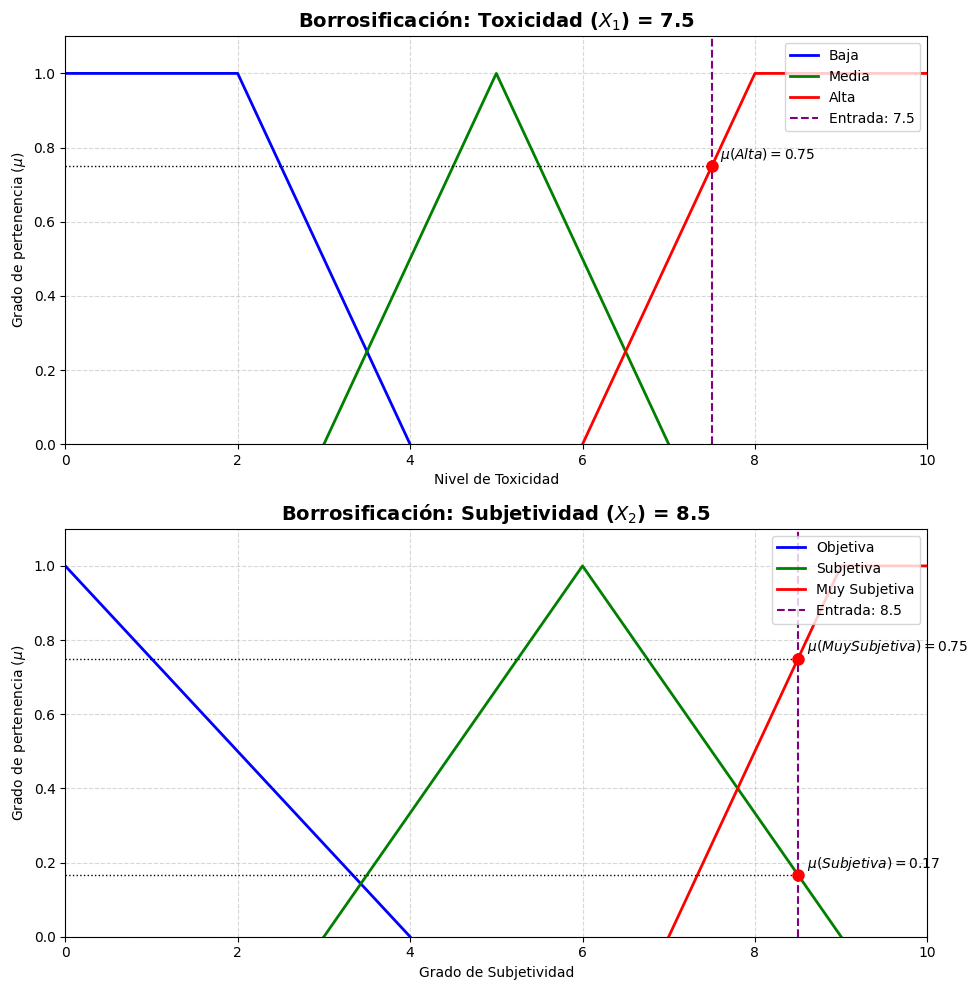

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURACIÓN DE LOS DATOS (Tus coordenadas originales) ---

# Variable 1: Toxicidad (0-10)
toxicidad = {
    'Baja':  {'x': [0, 2, 4],    'y': [1, 1, 0], 'color': 'blue'},
    'Media': {'x': [3, 5, 7],    'y': [0, 1, 0], 'color': 'green'},
    'Alta':  {'x': [6, 8, 10],   'y': [0, 1, 1], 'color': 'red'}
}

# Variable 2: Subjetividad (0-10)
subjetividad = {
    'Objetiva':       {'x': [0, 4, 4],   'y': [1, 0, 0], 'color': 'blue'}, 
    'Subjetiva':      {'x': [3, 6, 9],   'y': [0, 1, 0], 'color': 'green'},
    'Muy Subjetiva':  {'x': [7, 9, 10],  'y': [0, 1, 1], 'color': 'red'}
}

# --- ESCENARIOS DE ENTRADA ---
valor_tox = 7.5
valor_subj = 8.5

# --- CÁLCULO DE PERTENENCIA (Interpolación) ---
# Skfuzzy lo hace automático, pero aquí usamos numpy para no depender de la librería de control
mu_tox_alta = np.interp(valor_tox, toxicidad['Alta']['x'], toxicidad['Alta']['y'])
mu_tox_media = np.interp(valor_tox, toxicidad['Media']['x'], toxicidad['Media']['y'])

mu_subj_muy_subj = np.interp(valor_subj, subjetividad['Muy Subjetiva']['x'], subjetividad['Muy Subjetiva']['y'])
mu_subj_subj = np.interp(valor_subj, subjetividad['Subjetiva']['x'], subjetividad['Subjetiva']['y'])

# --- CREACIÓN DE LAS GRÁFICAS DE BORROSIFICACIÓN ---

fig, axs = plt.subplots(2, 1, figsize=(10, 10))
plt.subplots_adjust(hspace=0.4)

def plot_fuzzification(ax, data, title, xlabel, input_val, mu_results):
    # 1. Dibujar los conjuntos base
    for label, params in data.items():
        ax.plot(params['x'], params['y'], label=label, color=params['color'], linewidth=2)
    
    # 2. Dibujar la línea de entrada (X nítido)
    ax.axvline(x=input_val, color='purple', linestyle='--', linewidth=1.5, label=f'Entrada: {input_val}')
    
    # 3. Dibujar las intersecciones y líneas de pertenencia (Y borroso)
    for label, mu_val in mu_results.items():
        if mu_val > 0:
            # Línea horizontal desde la intersección al eje Y
            ax.axhline(y=mu_val, xmin=0, xmax=(input_val/10), color='black', linestyle=':', linewidth=1)
            # Punto rojo en la intersección
            ax.plot(input_val, mu_val, 'ro', markersize=8)
            # Texto explicativo
            ax.text(input_val + 0.1, mu_val + 0.02, f'$\mu({label}) = {mu_val:.2f}$', color='black', fontweight='bold')

    # Configuración de estilo (Look profesional)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Grado de pertenencia ($\mu$)')
    ax.set_ylim(0, 1.1)
    ax.set_xlim(0, 10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

# --- GRAFICAR CADA VARIABLE CON SUS RESULTADOS ---

# Resultados Toxicidad
resultados_tox = {'Alta': mu_tox_alta, 'Media': mu_tox_media}
plot_fuzzification(axs[0], toxicidad, 'Borrosificación: Toxicidad ($X_1$) = 7.5', 'Nivel de Toxicidad', valor_tox, resultados_tox)

# Resultados Subjetividad
resultados_subj = {'Muy Subjetiva': mu_subj_muy_subj, 'Subjetiva': mu_subj_subj}
plot_fuzzification(axs[1], subjetividad, 'Borrosificación: Subjetividad ($X_2$) = 8.5', 'Grado de Subjetividad', valor_subj, resultados_subj)

plt.tight_layout()
plt.show()

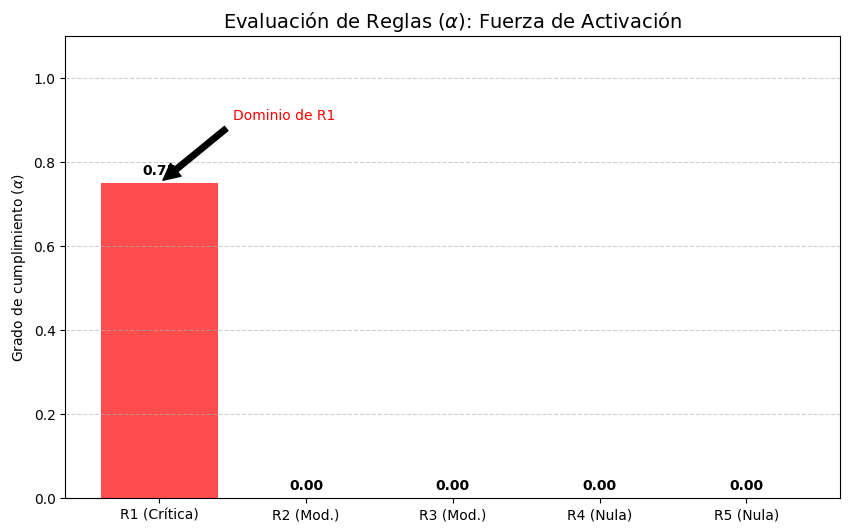

R1 (Crítica): Nivel de activación = 0.75
R2 (Mod.): Nivel de activación = 0.0
R3 (Mod.): Nivel de activación = 0.0
R4 (Nula): Nivel de activación = 0.0
R5 (Nula): Nivel de activación = 0.0


In [6]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# --- 1. VALORES PREVIAMENTE CALCULADOS (Borrosificación) ---
mu_tox_alta = 0.75
mu_tox_media = 0.0
mu_tox_baja = 0.0

mu_subj_muy_sub = 0.75
mu_subj_sub = 0.17
mu_subj_obj = 0.0

# --- 2. EVALUACIÓN DE REGLAS (Operador Mínimo para "Y") ---

# R1: Tox Alta Y Subj Muy Subjetiva
alfa_r1 = np.fmin(mu_tox_alta, mu_subj_muy_sub)

# R2: Tox Media Y Subj Subjetiva
alfa_r2 = np.fmin(mu_tox_media, mu_subj_sub)

# R3: Tox Alta Y Subj Objetiva
alfa_r3 = np.fmin(mu_tox_alta, mu_subj_obj)

# R4: Tox Baja (Regla simple)
alfa_r4 = mu_tox_baja

# R5: Subj Objetiva (Regla simple)
alfa_r5 = mu_subj_obj

# Guardamos los resultados en un diccionario para graficar
reglas_nombres = ['R1 (Crítica)', 'R2 (Mod.)', 'R3 (Mod.)', 'R4 (Nula)', 'R5 (Nula)']
valores_alfa = [alfa_r1, alfa_r2, alfa_r3, alfa_r4, alfa_r5]

# --- 3. GRÁFICA DE ACTIVACIÓN DE REGLAS ---

plt.figure(figsize=(10, 6))
colors = ['red' if v > 0 else 'gray' for v in valores_alfa]
bars = plt.bar(reglas_nombres, valores_alfa, color=colors, alpha=0.7)

# Añadir etiquetas de valor sobre las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', fontweight='bold')

plt.title('Evaluación de Reglas ($\\alpha$): Fuerza de Activación', fontsize=14)
plt.ylabel('Grado de cumplimiento ($\\alpha$)')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Explicación en el gráfico
plt.annotate('Dominio de R1', xy=(0, 0.75), xytext=(0.5, 0.9),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, color='red')

plt.show()

# Imprimir resultados por consola
for i, nombre in enumerate(reglas_nombres):
    print(f"{nombre}: Nivel de activación = {valores_alfa[i]}")

<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
C:\Users\willi\AppData\Local\Temp\ipykernel_17524\3943385856.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax0.set_ylabel('Grado de pertenencia ($\mu$)', fontsize=12)


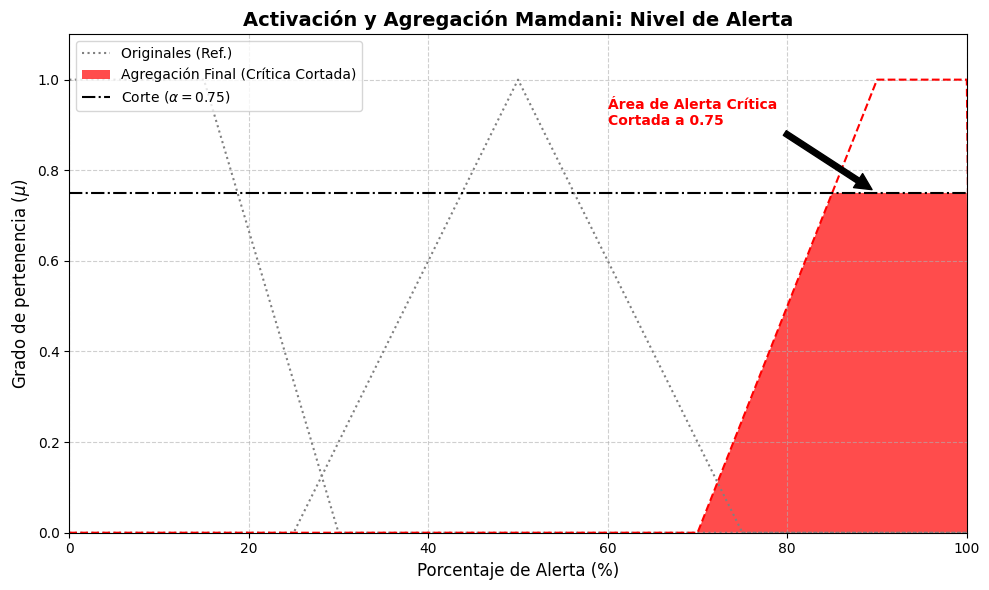

In [7]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# 1. Definir Universo de Discurso para la Salida (Nivel de Alerta 0-100%)
x_alerta = np.arange(0, 101, 0.5) # Resolución de 0.5 para suavidad

# 2. Definir los Conjuntos Borrosos de Salida Originales (Tus coordenadas)
alerta_nulo = fuzz.trapmf(x_alerta, [0, 0, 15, 30])
alerta_moderado = fuzz.trimf(x_alerta, [25, 50, 75])
alerta_critico = fuzz.trapmf(x_alerta, [70, 90, 100, 100])

# --- 3. DATOS DE ENTRADA (Nivel de Activación alpha calculado en el paso anterior) ---
# Alfa R1 (Tox Alta Y Subj Muy Subj) = 0.75
# Las demás reglas dieron alfa = 0
alfa_r1 = 0.75

# --- 4. ACTIVACIÓN (Corte / Implicación) ---
# Usamos np.fmin para "cortar" el conjunto de salida Crítico a la altura de alfa_r1
activacion_critica = np.fmin(alfa_r1, alerta_critico)

# --- 5. AGREGACIÓN (Unión / Máximo) ---
# Como solo R1 se activó significativamente, la agregación es solo el área cortada.
# Usamos np.fmax para combinar (aquí solo hay una, pero así se hace)
agregacion_final = np.fmax(activacion_critica, 0) # El 0 representa la agregación de R2-R5

# --- GRÁFICA DE ACTIVACIÓN Y AGREGACIÓN ---

fig, ax0 = plt.subplots(figsize=(10, 6))

# Dibujar los conjuntos originales de fondo (Gris claro para referencia)
ax0.plot(x_alerta, alerta_nulo, 'gray', linestyle=':', label='Originales (Ref.)')
ax0.plot(x_alerta, alerta_moderado, 'gray', linestyle=':')
ax0.plot(x_alerta, alerta_critico, 'red', linestyle='--') # Solo marcamos el Crítico original

# Dibujar el área de Agregación Final (Sombreada)
ax0.fill_between(x_alerta, 0, agregacion_final, facecolor='red', alpha=0.7, label='Agregación Final (Crítica Cortada)')

# Dibujar la línea de "Corte" alpha=0.75
ax0.axhline(y=alfa_r1, color='black', linestyle='-.', linewidth=1.5, label=f'Corte ($\\alpha=0.75$)')

# Etiquetas y Estilo
ax0.set_title('Activación y Agregación Mamdani: Nivel de Alerta', fontsize=14, fontweight='bold')
ax0.set_xlabel('Porcentaje de Alerta (%)', fontsize=12)
ax0.set_ylabel('Grado de pertenencia ($\mu$)', fontsize=12)
ax0.set_ylim(0, 1.1)
ax0.set_xlim(0, 100)
ax0.grid(True, linestyle='--', alpha=0.6)
ax0.legend(loc='upper left')

# Anotación explicativa
ax0.annotate('Área de Alerta Crítica\nCortada a 0.75', xy=(90, 0.75), xytext=(60, 0.9),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()


Resultado Final del Nivel de Alerta: 88.46%


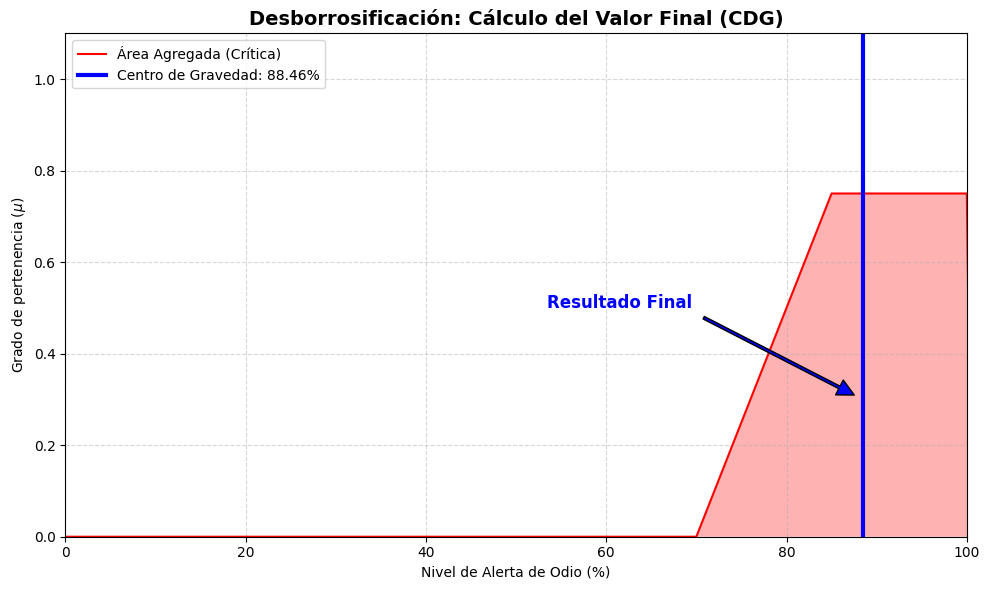

In [8]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# --- 1. DATOS PREVIOS (Universo y Agregación) ---
x_alerta = np.arange(0, 101, 0.5)
# Recreamos la Alerta Crítica cortada a 0.75 (del paso anterior)
alerta_critico = fuzz.trapmf(x_alerta, [70, 90, 100, 100])
agregacion_final = np.fmin(0.75, alerta_critico)

# --- 2. DESBORROSIFICACIÓN (Centro de Gravedad) ---
# 'centroid' es el método matemático para el Centro de Gravedad (CDG)
resultado_nítido = fuzz.defuzz(x_alerta, agregacion_final, 'centroid')

print(f"Resultado Final del Nivel de Alerta: {resultado_nítido:.2f}%")

# --- 3. GRÁFICA FINAL DE DESBORROSIFICACIÓN ---
fig, ax0 = plt.subplots(figsize=(10, 6))

# Dibujamos el área agregada (lo que el sistema "sabe")
ax0.plot(x_alerta, agregacion_final, 'r', linewidth=1.5, label='Área Agregada (Crítica)')
ax0.fill_between(x_alerta, 0, agregacion_final, facecolor='red', alpha=0.3)

# Dibujamos la línea del Centro de Gravedad (el resultado final)
ax0.axvline(x=resultado_nítido, color='blue', linestyle='-', linewidth=3, 
            label=f'Centro de Gravedad: {resultado_nítido:.2f}%')

# Elementos visuales para el informe
ax0.set_title('Desborrosificación: Cálculo del Valor Final (CDG)', fontsize=14, fontweight='bold')
ax0.set_xlabel('Nivel de Alerta de Odio (%)')
ax0.set_ylabel(r'Grado de pertenencia ($\mu$)')
ax0.set_ylim(0, 1.1)
ax0.set_xlim(0, 100)
ax0.grid(True, linestyle='--', alpha=0.5)
ax0.legend(loc='upper left')

# Anotación del punto de equilibrio
ax0.annotate('\nResultado Final', 
             xy=(resultado_nítido, 0.3), xytext=(resultado_nítido - 35, 0.5),
             arrowprops=dict(facecolor='blue', shrink=0.05, width=2),
             fontsize=12, color='blue', fontweight='bold')

plt.tight_layout()
plt.show()
